# 5b · Cross-dataset transfer evaluation — SENTENCE heads (Type-2)

Companion to notebook 5. Same protocol, but it benchmarks the **deployed Type-2 sentence heads** (`*_sentence_s1*`) in the **sentence regime** (one factual sentence per question) with **LLM-judge labels** (BLEURT is invalid on sentences — the reason the judge exists). Nothing is re-fit on the targets, so every row is held out.

Headline vs nb5 (Type-1 short-QA heads): does per-sentence detection hold across datasets, and is **TSV** still the length-robust head? `FUSED` is a lightweight **3-feature** logreg (TSV-dominant — see the printed weights) fit OOF on the sentence training data; the deployed TSV-only `fusion_claim_s1` is untouched. Saved to `data/<ds>_cross_eval_sentence_s1.parquet` (separate from nb5's files).

In [1]:
import os, sys
os.environ.setdefault('HF_HOME', r'D:/LLAMA CACHE/huggingface')  # reuse local LLaMA cache
sys.path.insert(0, os.path.abspath(os.path.join('..', 'hallking')))
import warnings; warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.join('..','tools'))
from cross_eval import evaluate_many
import fit_sentence_fusion
# ---- CONFIG -------------------------------------------------------------------------------
DATASETS = ['squad', 'triviaqa', 'web_questions']  # clean QA sets (nq_open dropped: stale/ambiguous gold)
TRAIN    = 'triviaqa'                          # heads were trained on this
N        = 150                                 # questions per dataset
OFFSETS  = {'triviaqa': 3000}                  # keep TriviaQA held-out (training used offset 0)
HEAD_SET = 'sentence_s1'                        # Type-2 deployed sentence heads (vs nb5's 'retrained' Type-1)
# ------------------------------------------------------------------------------------------
fit_sentence_fusion.main()                     # (re)fit the 3-feature TSV-dominant eval fusion (CPU, secs)
SCORED = evaluate_many(DATASETS, train_ds=TRAIN, n=N, offsets=OFFSETS, head_set=HEAD_SET)
print('done:', list(SCORED.keys()))

fit on data\claims_s1j.parquet OOF test split (n=125, halluc=20.0%)
standardized logreg weights (|w| = influence; higher halluc = positive):
  tsv_margin   +0.894
  hallushift   +0.208
  sep_entropy  +0.103
intercept     -0.293
saved -> models\fusion_sentence_s1_3feat.pkl

############## squad  (n=150, offset=0) ##############
==== 1. generate + cache features on squad (regime=sentence, labels=llm_judge) ====


Using the latest cached version of the dataset since squad couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'plain_text' at D:\LLAMA CACHE\huggingface\datasets\squad\plain_text\0.0.0\7b6d24c440a36b6815f21b70d25016731768db1f (last modified on Mon Mar 30 15:38:13 2026).


[HallKing] loading meta-llama/Meta-Llama-3.1-8B-Instruct (4bit=True) ...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
Loading weights: 100%|██████████| 291/291 [01:58<00:00,  2.45it/s]


[HallKing] model ready | num_layers=32 | device=cuda:0


...

[HallKing] model unloaded.
  labels (llm_judge): truthful=128 halluc=22 (14.7%) over 150 answers
   n=150  balance: truthful=128 halluc=22 (14.7% halluc)
==== 2. score SEP + HalluShift heads (trained on triviaqa) ====
==== 3. score TSV head (trained on triviaqa) on Instruct model ====
[HallKing] loading meta-llama/Meta-Llama-3.1-8B-Instruct (4bit=True) ...


Loading weights: 100%|██████████| 291/291 [00:50<00:00,  5.71it/s]


[HallKing] model ready | num_layers=32 | device=cuda:0
[TSV] loaded checkpoint | layer=9 lam=5.0 cos_temp=0.1 | trained AUROC=0.8165


TSV scoring: 100%|██████████| 150/150 [00:21<00:00,  6.86q/s]


[HallKing] model unloaded.
==== 4. fusion + evaluation ====

=== sentence_s1 heads (triviaqa) -> web_questions (transfer, all rows held out) ===
            AUROC   AUPR     F1
detector                       
SEP         0.479  0.184  0.280
HalluShift  0.532  0.154  0.299
TSV         0.537  0.165  0.292
FUSED       0.539  0.172  0.294

saved d:\Github Repositories\HallKing\data\web_questions_cross_eval_sentence_s1.parquet
done: ['squad', 'triviaqa', 'web_questions']


### Per-dataset metrics (AUROC / AUPR / Accuracy / Precision / Recall / F1)

In [2]:
import os, sys
os.environ.setdefault('HF_HOME', r'D:/LLAMA CACHE/huggingface')  # reuse local LLaMA cache
sys.path.insert(0, os.path.abspath(os.path.join('..', 'hallking')))
import warnings; warnings.filterwarnings('ignore')
import metrics as M, pandas as pd, numpy as np
DETS = {'SEP':'sep_entropy', 'HalluShift':'hallushift', 'TSV':'tsv_margin', 'FUSED':'fused'}
METRICS = {}
for ds, (_, df) in SCORED.items():
    y = df['hallucination'].to_numpy()
    res = {}
    for name, col in DETS.items():
        s = df[col].to_numpy()
        m = M.detector_metrics(y, s, threshold=M.best_threshold(y, s))
        M.attach_curves(m, y, s)
        res[name] = m
    METRICS[ds] = res
    print(f'\n=== {ds}  (n={len(df)}, halluc={y.mean()*100:.1f}%) ===')
    print(M.summary_table(res).to_string())


=== squad  (n=139, halluc=33.1%) ===
             AUROC    AUPR  Accuracy  Precision  Recall      F1
detector                                                       
SEP         0.7321  0.5717    0.7266     0.5625  0.7826  0.6545
HalluShift  0.5404  0.3795    0.3309     0.3309  1.0000  0.4973
TSV         0.6912  0.4909    0.6691     0.5000  0.6957  0.5818
FUSED       0.7020  0.4872    0.6691     0.5000  0.8261  0.6230

=== triviaqa  (n=150, halluc=21.3%) ===
             AUROC    AUPR  Accuracy  Precision  Recall      F1
detector                                                       
SEP         0.7055  0.3611    0.6467     0.3433  0.7188  0.4646
HalluShift  0.4523  0.2375    0.2400     0.2153  0.9688  0.3523
TSV         0.5718  0.3007    0.5600     0.2703  0.6250  0.3774
FUSED       0.5847  0.2876    0.5867     0.2857  0.6250  0.3922

=== web_questions  (n=150, halluc=14.7%) ===
             AUROC    AUPR  Accuracy  Precision  Recall      F1
detector                                   

### ROC / PR curves + confusion matrices per dataset

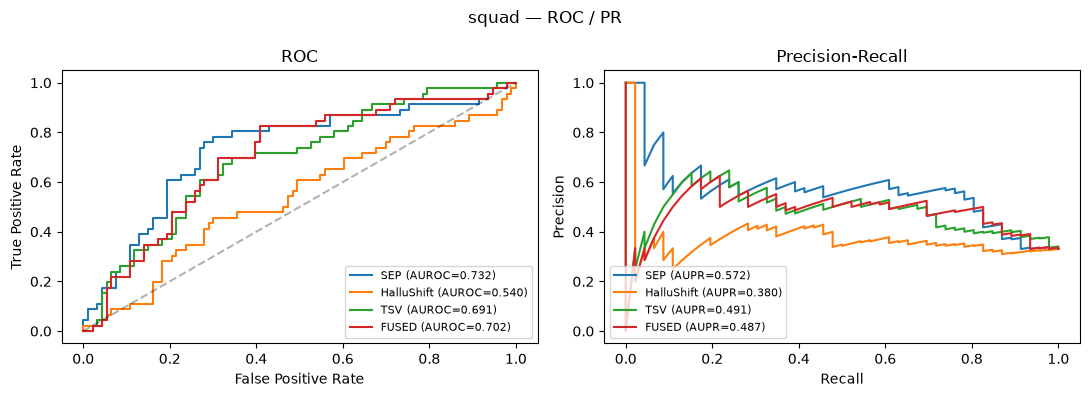

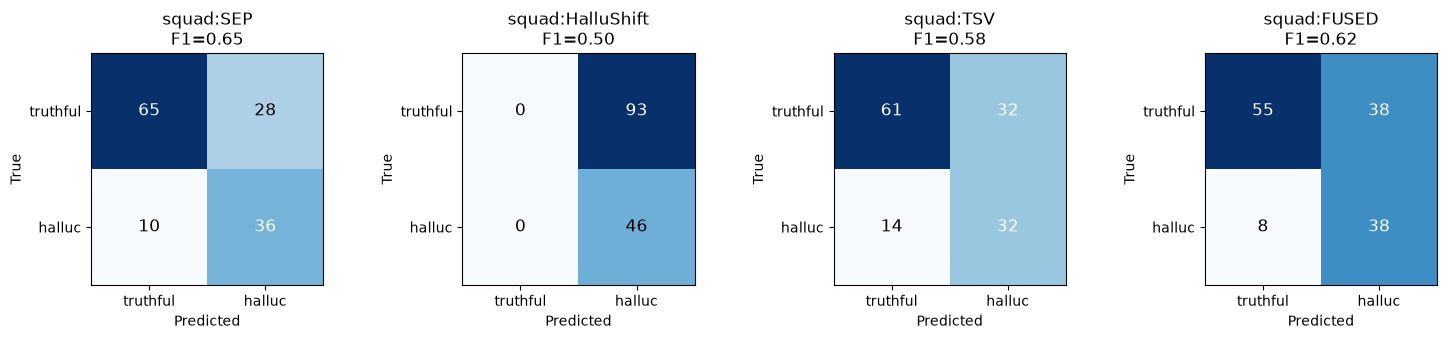

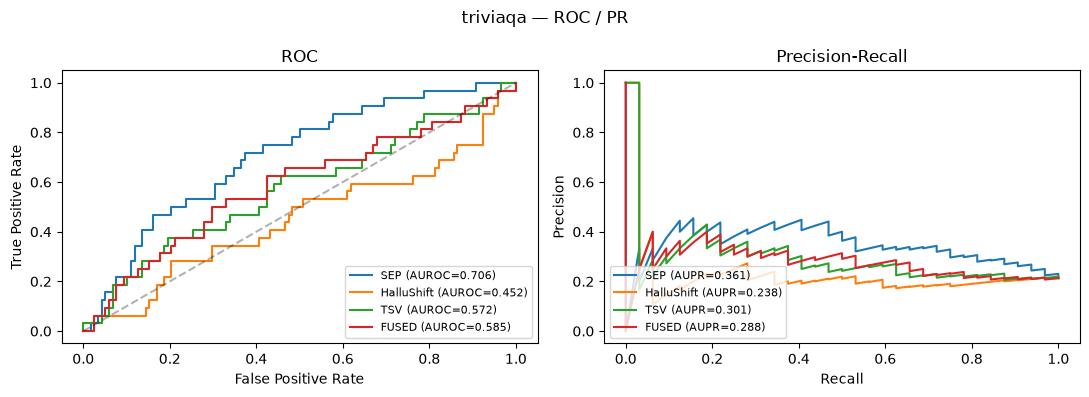

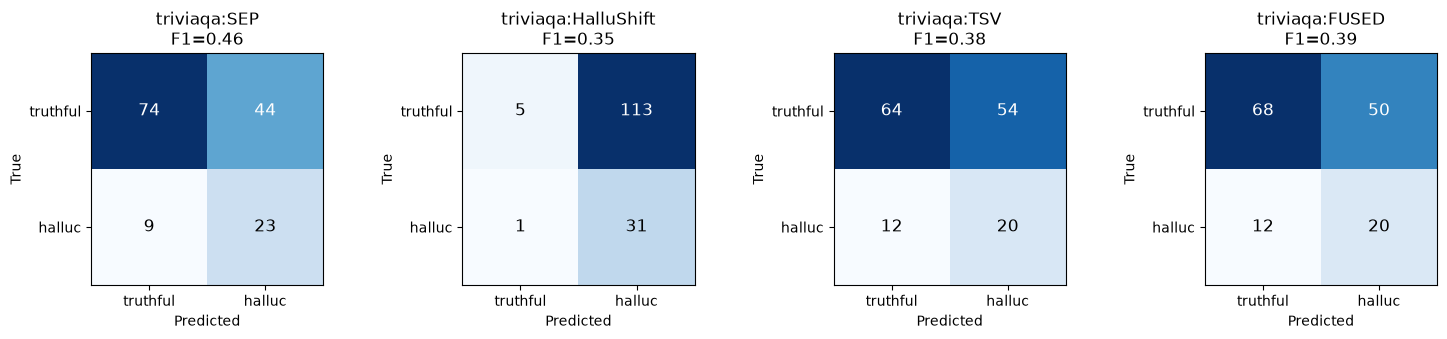

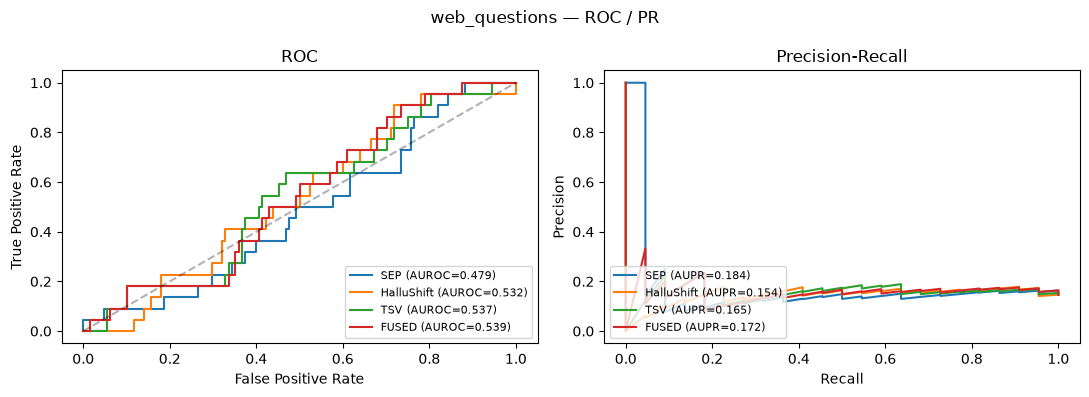

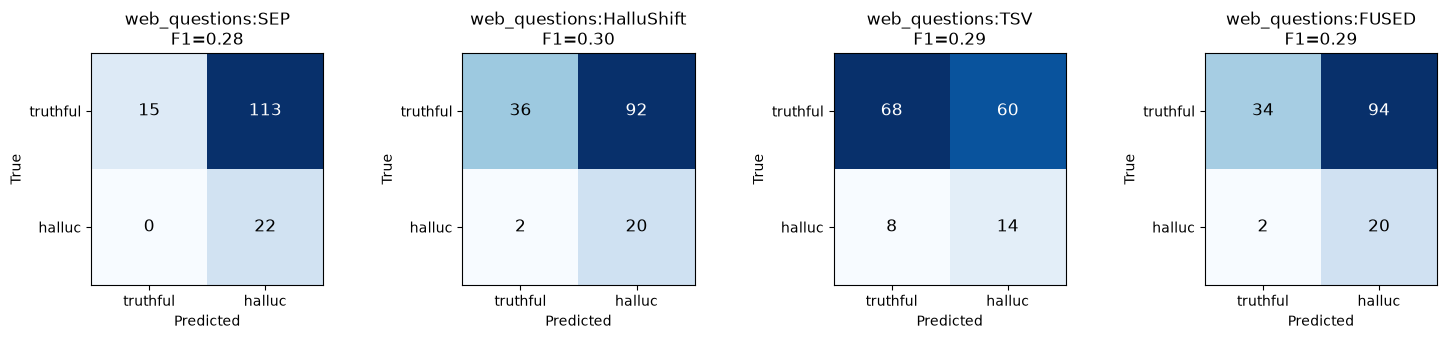

In [3]:
import matplotlib.pyplot as plt
for ds, res in METRICS.items():
    fig, ax = plt.subplots(1, 2, figsize=(11,4))
    M.plot_roc(ax[0], res); M.plot_pr(ax[1], res)
    fig.suptitle(f'{ds} — ROC / PR'); plt.tight_layout(); plt.show()
    fig, axes = plt.subplots(1, 4, figsize=(15,3.4))
    for axx,(name,m) in zip(axes, res.items()):
        M.plot_confusion(axx, m['confusion_matrix'], title=f"{ds}:{name}\nF1={m['F1']:.2f}")
    plt.tight_layout(); plt.show()

### Headline — does FUSED stay on top across datasets?

Pivot tables (rows = dataset, cols = detector). Watch the **best single detector change** between rows while **FUSED stays ≥ the best single** — that is the robustness story.

In [4]:
for metric in ['AUROC','AUPR','F1']:
    piv = pd.DataFrame({ds:{name:res[name][metric] for name in DETS}
                        for ds,res in METRICS.items()}).T.round(3)
    piv['best_single'] = piv[['SEP','HalluShift','TSV']].idxmax(axis=1)
    piv['FUSED_wins'] = piv['FUSED'] >= piv[['SEP','HalluShift','TSV']].max(axis=1)
    print(f'\n=== {metric} (rows=dataset, cols=detector) ===')
    print(piv.to_string())


=== AUROC (rows=dataset, cols=detector) ===
                 SEP  HalluShift    TSV  FUSED best_single  FUSED_wins
squad          0.732       0.540  0.691  0.702         SEP       False
triviaqa       0.706       0.452  0.572  0.585         SEP       False
web_questions  0.479       0.532  0.537  0.539         TSV        True

=== AUPR (rows=dataset, cols=detector) ===
                 SEP  HalluShift    TSV  FUSED best_single  FUSED_wins
squad          0.572       0.380  0.491  0.487         SEP       False
triviaqa       0.361       0.238  0.301  0.288         SEP       False
web_questions  0.184       0.154  0.165  0.172         SEP       False

=== F1 (rows=dataset, cols=detector) ===
                 SEP  HalluShift    TSV  FUSED best_single  FUSED_wins
squad          0.655       0.497  0.582  0.623         SEP       False
triviaqa       0.465       0.352  0.377  0.392         SEP       False
web_questions  0.280       0.299  0.292  0.294  HalluShift       False
